## Langgraph Chatbot with tools

In [2]:
from dotenv import load_dotenv
import os

load_dotenv()
os.environ['OPENAI_API_KEY'] = os.getenv('OPENAI_API_KEY')
os.environ['TAVILY_API_KEY'] = os.getenv('TAVILY_API_KEY')

os.environ['LANGSMITH_TRACING'] = 'true'
os.environ['LANGSMITH_ENDPOINT'] = 'https://apac.api.smith.langchain.com'
os.environ['LANGSMITH_PROJECT'] = 'skn34-langchain'
os.environ['LANGSMITH_API_KEY'] = os.getenv('LANGSMITH_API_KEY')

### 도구 정의

In [3]:
# Tavily Search 도구 생성 및 검색
from langchain_tavily import TavilySearch

tavily_tool = TavilySearch(max_results=3)
tavily_tool.invoke('랭그래프의 노드와 엣지가 뭐야?')

Failed to multipart ingest runs: langsmith.utils.LangSmithError: Failed to POST https://apac.api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://apac.api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


{'query': '랭그래프의 노드와 엣지가 뭐야?',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://databoom.tistory.com/entry/LangGraph-%EB%85%B8%EB%93%9Cnode%EC%99%80-%EC%97%A3%EC%A7%80edge',
   'title': '[LangGraph] 노드(node)와 엣지(edge) - 인공지능 개발자 수다',
   'content': '## 1. 노드 (Node)\n\n### 1.1.  노드 개념\n\n노드는 데이터를 입력받아 처리한 뒤 결과를 반환하는 실행 단위다.  \nLangGraph에서는 파이썬 함수나 Runnable 객체, 클래스 형태로 정의할 수 있다.\n\n 특징\n  + 하나의 노드는 하나의 역할에 집중하는 것이 좋다.\n  + 입력과 출력은 State를 기반으로 한다.\n  + 노드의 이름은 고유해야 한다.\n\n### 1.2. 노드 만드는 법 기본\n\n#### 1.2.1. 함수로 노드 만들기\n\n입력\n\n state 를 입력으로 받음\n\nreturn 규칙\n\n 반드시 dict 형식으로 반환해야 하며, key는 State에서 정의한 필드와 일치해야 함.\n LangGraph는 이 dict를 기존 state에 \\\\병합(merge)\\\\한다.\n 필요한 필드만 반환해도 되고, 나머지는 이전 state 값이 유지된다.\n\ngraph에 노드 추가하기 [...] ### 2.1. 엣지 개념\n\n엣지는 노드와 노드를 연결하는 경로다. 데이터가 한 노드에서 다음 노드로 흘러가는 길이라고 보면 된다.  \n   \n특징\n\n 엣지는 시작 노드와 도착 노드를 지정해야 한다.\n 조건부 엣지를 설정해 흐름을 분기시킬 수 있다.\n 한 노드에서 여러 노드로 데이터를 보낼 수도 있다.\n\n### 2.2. 엣지 만드는 방법\n\n#### 2.2.1. 일반 edge\n

### 그래프 구성

In [10]:
from typing import TypedDict, Annotated, List     # 타입 힌트 도구
from langgraph.graph.message import add_messages  # 메시지 누적 처리를 해줄 헬퍼
from langchain.chat_models import init_chat_model
from langchain_core.messages import AIMessage, HumanMessage, SystemMessage  # 메시지 타입

# 그래프에서 사용할 상태(TypedDict) 스키마
class State(TypedDict):
    messages: Annotated[List, add_messages]  # messages 필드가 add_messages 규칙으로 누적 저장  # 튜플형으로 저장

llm = init_chat_model('gpt-5.4-mini')
tools = [tavily_tool]
llm_with_tools = llm.bind_tools(tools)  # llm에 도구 스펙 바인딩

# State의 messages를 입력으로 받아, 응답 메시지를 추가해주는 노드 함수
def chatbot(state: State):
    response = llm_with_tools.invoke(state['messages'])  # 누적된 메시지 리스트로 LLM 호출
    return {'messages': [response]}  # add_messages 규칙에 의해 기존 messages에 응답이 누적됨

In [5]:
from langchain_core.messages import ToolMessage  # 툴 실행 결과를 담을 메시지 타입
import json  # json 문자열 파싱

# tool call을 실행하는 노드 클래스
class ToolNode:
    def __init__(self, tools):
        self.tools_by_name = {tool.name: tool for tool in tools}  # {tool_name: tool 객체}

    def __call__(self, inputs: State):
        """
        도구 호출을 처리하는 메서드입니다.

        Args:
            inputs (dict): 입력 상태 딕셔너리. 'messages' 키에 메시지 리스트가 포함되어야 합니다.

        Returns:
            dict: 도구 실행 결과를 담은 메시지 리스트가 포함된 딕셔너리.
                 형식: {"messages": [ToolMessage, ...]}

        Raises:
            ValueError: 입력에 메시지가 없는 경우 발생합니다.
        """
        # messages가 있으면 마지막 메시지 가져오고, 아니면 에러 발생
        if messages := inputs.get("messages"):
            message = messages[-1]  # 마지막 메시지(AI Message)는 도구 호출 대상
        else:
            raise ValueError("메시지가 없습니다.")

        outputs = []  # ToolMessage 들을 담을 리스트

        # 마지막 메시지(AI Message)에 포함된 tool_calls를 순회
        for tool_call in message.tool_calls:
            # tool 이름을 찾아 실행 (매개변수는 ai 메시지에서 전달한 입력매개변수)
            tool_result = self.tools_by_name[tool_call['name']].invoke(tool_call['agrs'])
            tool_message = ToolMessage(
                content=json.dump(tool_result),  # 결과를 json으로 파싱
                name = tool_call,
                tool_call_id = tool_call['id']
            )
            outputs.append(tool_message)

        return {"messages": outputs}

In [6]:
# 도구 호출 여부에 따른 분기 함수 (tools_condition) : 다음 분기로 tools 보낼지, 아니면 END로 끝낼지 결정
from pprint import pprint

def tools_condition(state: State):
    pprint(state['messages'])

    if isinstance(state, list):  # state가 list 형태인 경우 (MessageGraph)
        ai_message = state[-1]  # 마지막 메시지는 AIMessage
    elif messages := state.get("messages", []):  # state가 dict 형태(StateGraph)인 경우
        ai_message = messages[-1]
    else:
        raise ValueError(f"State의 tool_edge에서 들어온 메시지 확인 불가: {state}")

    # AIMessage의 tool_calls가 있으면 도구 노드로 이동
    if hasattr(ai_message, "tool_calls") and len(ai_message.tool_calls) > 0:
        return 'tools'

    # tool_calls가 없으면 END 노드로 이동
    return END

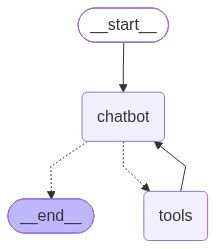

In [ ]:
# 직접 구현한 ToolNode와 tools_condition 함수 사용한 워크플로우
from langgraph.graph import StateGraph, START, END

workflow = StateGraph(State)  # State 스키마 기반 그래프 설계 객체 생성
tool_node = ToolNode(tools)

workflow.add_edge(START, 'chatbot')   # 시작 노드 -> chatbot 노드

workflow.add_node('chatbot', chatbot)  # chatbot 노드
workflow.add_node('tools', tool_node)  # tools 노드

workflow.add_conditional_edges('chatbot', tools_condition, {'tools': 'tools', END: END})
workflow.add_edge('tools', 'chatbot')

graph = workflow.compile()  # 설계된 워크플로우를 실행 가능한 그래프로 컴파일

graph  # 그래프 객체

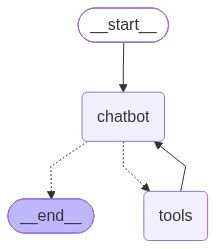

In [ ]:
# langgraph.prebuilt 모듈의 ToolNode와 tools_condition 함수 사용한 워크플로우
from langgraph.prebuilt import ToolNode, tools_condition

workflow = StateGraph(State)  # State 스키마 기반 그래프 설계 객체 생성
tool_node = ToolNode(tools)

workflow.add_edge(START, 'chatbot')   # 시작 노드 -> chatbot 노드

workflow.add_node('chatbot', chatbot)  # chatbot 노드
workflow.add_node('tools', tool_node)  # tools 노드

workflow.add_conditional_edges('chatbot', tools_condition, {'tools': 'tools', END: END})
workflow.add_edge('tools', 'chatbot')

graph = workflow.compile()  # 설계된 워크플로우를 실행 가능한 그래프로 컴파일

graph  # 그래프 객체

In [ ]:
user_query = '랭그래프의 구성요소는?'

state = {'messages': [HumanMessage(content=user_query)]}  # HumanMessage 객체 내 메시지 구현

response = graph.invoke(state)  # 그래프 실행 (START -> CHATBOT -> (tool 루프) or END)
pprint(response)
print('=' * 100)
print(response['messages'][-1].content)

Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://apac.api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://apac.api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


{'messages': [HumanMessage(content='랭그래프의 구성요소는?', additional_kwargs={}, response_metadata={}, id='2c1f2efd-52fc-443f-a92c-507888818caf'),
              AIMessage(content='랭그래프(LangGraph)의 핵심 구성요소는 보통 아래처럼 이해하면 됩니다.\n\n1. **Node(노드)**\n   - 그래프 안에서 실행되는 작업 단위입니다.\n   - 예: LLM 호출, 툴 실행, 상태 업데이트, 조건 판단 등\n\n2. **Edge(엣지)**\n   - 노드와 노드를 연결하는 흐름입니다.\n   - 어떤 노드 다음에 어떤 노드로 갈지 정의합니다.\n\n3. **State(상태)**\n   - 그래프가 실행되는 동안 공유되는 데이터입니다.\n   - 예: 대화 기록, 중간 결과, 사용자 입력, 플래그 값 등\n\n4. **Graph(그래프)**\n   - 노드와 엣지를 묶어서 전체 워크플로우를 구성한 것입니다.\n   - LangGraph에서는 보통 **StateGraph**를 많이 사용합니다.\n\n5. **Conditional Edge(조건부 엣지)**\n   - 상태나 결과에 따라 다음 노드를 다르게 선택하는 분기입니다.\n   - 예: “응답이 충분하면 종료, 아니면 재시도”\n\n6. **Entry / Exit Point**\n   - 그래프가 시작되는 지점과 종료되는 지점입니다.\n   - 보통 시작 노드와 종료 노드를 지정합니다.\n\n7. **Checkpoint / Memory**\n   - 실행 중간 상태를 저장하고 복구하기 위한 기능입니다.\n   - 대화형 에이전트나 재시작 가능한 워크플로우에 유용합니다.\n\n8. **Tool / Agent 연동**\n   - 외부 도구 검색, DB 조회, API 호출 등을 노드로 연결할 수 있습니다.\n   - 에이전트 패턴을 만들 때 자주 사용됩니다.\n\n한 줄로 요약하면:

Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://apac.api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://apac.api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


In [13]:
user_query = '최근 우리나라의 산불 횟수는?'

state = {'messages': [HumanMessage(content=user_query)]}  # HumanMessage 객체 내 메시지 구현

response = graph.invoke(state)  # 그래프 실행 (START -> CHATBOT -> (tool 루프) or END)
pprint(response)
print('=' * 100)
print(response['messages'][-1].content)

Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://apac.api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://apac.api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')
Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://apac.api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://apac.api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')
Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://apac.api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://apac.api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


{'messages': [HumanMessage(content='최근 우리나라의 산불 횟수는?', additional_kwargs={}, response_metadata={}, id='b055b3f8-b5e8-4a0b-a8ca-51ef0fd95f72'),
              AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 74, 'prompt_tokens': 1279, 'total_tokens': 1353, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0, 'text_tokens': None}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 1152, 'image_tokens': None, 'text_tokens': None}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-mini-2026-03-17', 'system_fingerprint': None, 'id': 'chatcmpl-EJqYsuUdQnmjL7TnBcFTXvYZfoMCm', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--01a064e2-df60-7f03-9f9c-1c7380446f5a-0', tool_calls=[{'name': 'tavily_search', 'args': {'query': '대한민국 최근 산불 발생 횟수 통계 2024 산림청', 'include_domain

Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://apac.api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://apac.api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')
